In [9]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200
from afqinsight import AFQDataset
from afqinsight.nn.utils import prep_pytorch_data
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal
from sklearn.decomposition import PCA
import afqinsight.augmentation as aug
from afqinsight.nn.pt_models import Conv1DAutoencoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
import sys 
sys.path.insert(1, '/Users/samchou/AFQ-Insight-Autoencoder-Plotting/Experiment_Utils')
# sys.path.insert(1, '/mmfs1/gscratch/nrdg/samchou/AFQ-Insight-Autoencoder-Experiments/Experiment_Utils')
from utils import train_variational_autoencoder, train_autoencoder, select_device, prep_fa_dataset, prep_first_tract_data, prep_fa_flattned_data
from models import Conv1DAutoencoder_fa, Conv1DVariationalAutoencoder_fa

In [11]:
device = select_device()

Using device: mps

Using MPS backend on macOS. (Detailed memory info may not be available.)


In [12]:
dataset = AFQDataset.from_study('hbn')
torch_dataset, train_loader, test_loader, val_loader = prep_pytorch_data(dataset,batch_size=256)  
gt_shape = torch_dataset[0][1].size()[0]
sequence_length = torch_dataset[0][0].size()[0]  # 48
in_channels = torch_dataset[0][0].size()[1]  # 100


File /Users/samchou/.cache/afq-insight/hbn/subjects.tsv exists.
File /Users/samchou/.cache/afq-insight/hbn/nodes.csv exists.


/Users/samchou/src/nrdg/AFQ-Insight/afqinsight/transform.py:144: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  features = interpolated.stack(["subjectID", "tractID", "metric"]).unstack(


In [13]:
torch_dataset, all_tracts_train_loader, all_tracts_test_loader, all_tracts_val_loader = prep_fa_flattned_data(dataset, batch_size=128)

In [14]:
latent_dim = 64  # Same latent dimension as the saved model
dropout = 0.0    # Same dropout rate as the saved model

# Create a new model instance
model = Conv1DVariationalAutoencoder_fa(latent_dims=latent_dim, dropout=dropout).to(device)

# Load weights - adjust file path as needed
# If loading on CPU from a model trained on GPU, use map_location
model.load_state_dict(torch.load('model_weights/best_vae.pth', map_location=device))
# model.load_state_dict(torch.load('model_weights/best_combined_model.pth', map_location=device))


# Set model to evaluation mode for inference
model.eval()

/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_1362/2700178228.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_weigh

RuntimeError: Error(s) in loading state_dict for Conv1DVariationalAutoencoder_fa:
	Missing key(s) in state_dict: "encoder.conv1.weight", "encoder.conv1.bias", "encoder.conv2.weight", "encoder.conv2.bias", "encoder.conv3.weight", "encoder.conv3.bias", "encoder.fc_mean.weight", "encoder.fc_mean.bias", "encoder.fc_logvar.weight", "encoder.fc_logvar.bias", "decoder.fc.weight", "decoder.fc.bias", "decoder.deconv2.weight", "decoder.deconv2.bias", "decoder.deconv3.weight", "decoder.deconv3.bias", "decoder.deconv4.weight", "decoder.deconv4.bias". 
	Unexpected key(s) in state_dict: "vae.encoder.conv1.weight", "vae.encoder.conv1.bias", "vae.encoder.conv2.weight", "vae.encoder.conv2.bias", "vae.encoder.conv3.weight", "vae.encoder.conv3.bias", "vae.encoder.fc_mean.weight", "vae.encoder.fc_mean.bias", "vae.encoder.fc_logvar.weight", "vae.encoder.fc_logvar.bias", "vae.decoder.fc.weight", "vae.decoder.fc.bias", "vae.decoder.deconv2.weight", "vae.decoder.deconv2.bias", "vae.decoder.deconv3.weight", "v

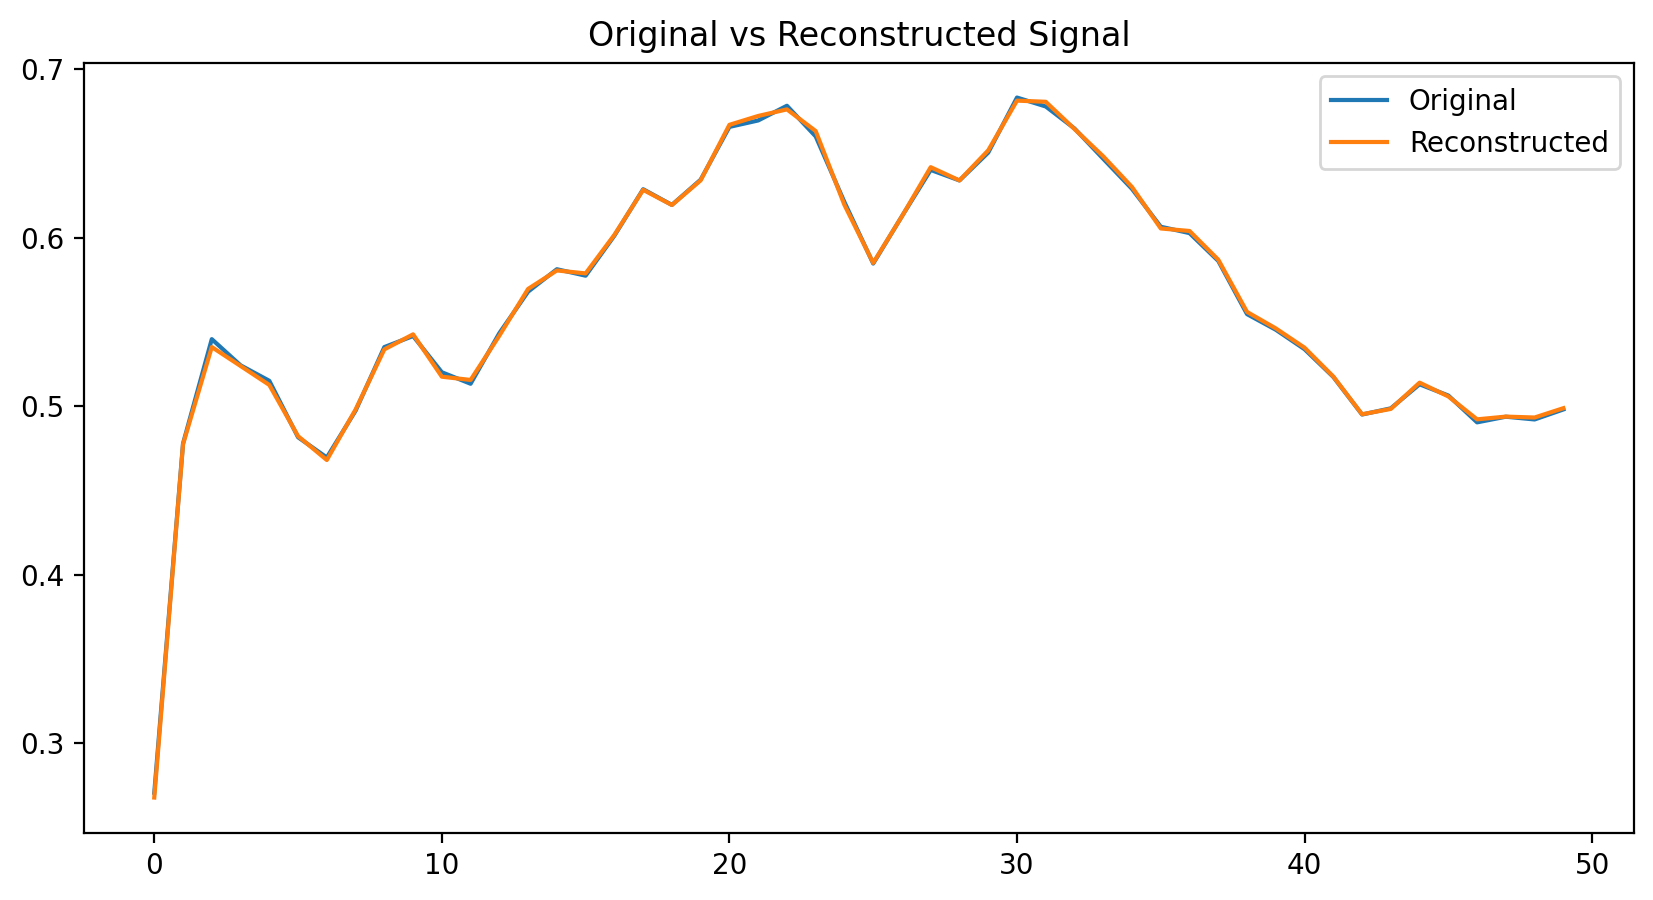

In [ ]:
# Example of using the loaded model for reconstruction
with torch.no_grad():  # No gradient tracking needed for inference
    # Prepare your test sample
    test_sample = all_tracts_test_loader.dataset[0][0][0:1].unsqueeze(0).to(device)  # Shape should be (batch_size, 1, sequence_length)
    
    # Get reconstruction
    reconstructed, mean, logvar = model(test_sample)
    
    # Now you can compare the original and reconstructed data
    # For example, plotting them
    import matplotlib.pyplot as plt
    
    # For a single example in the batch
    original = test_sample[0, 0].cpu().numpy()
    recon = reconstructed[0, 0].cpu().numpy()
    
    plt.figure(figsize=(10, 5))
    plt.plot(original, label='Original')
    plt.plot(recon, label='Reconstructed')
    plt.legend()
    plt.title('Original vs Reconstructed Signal')
    plt.show()

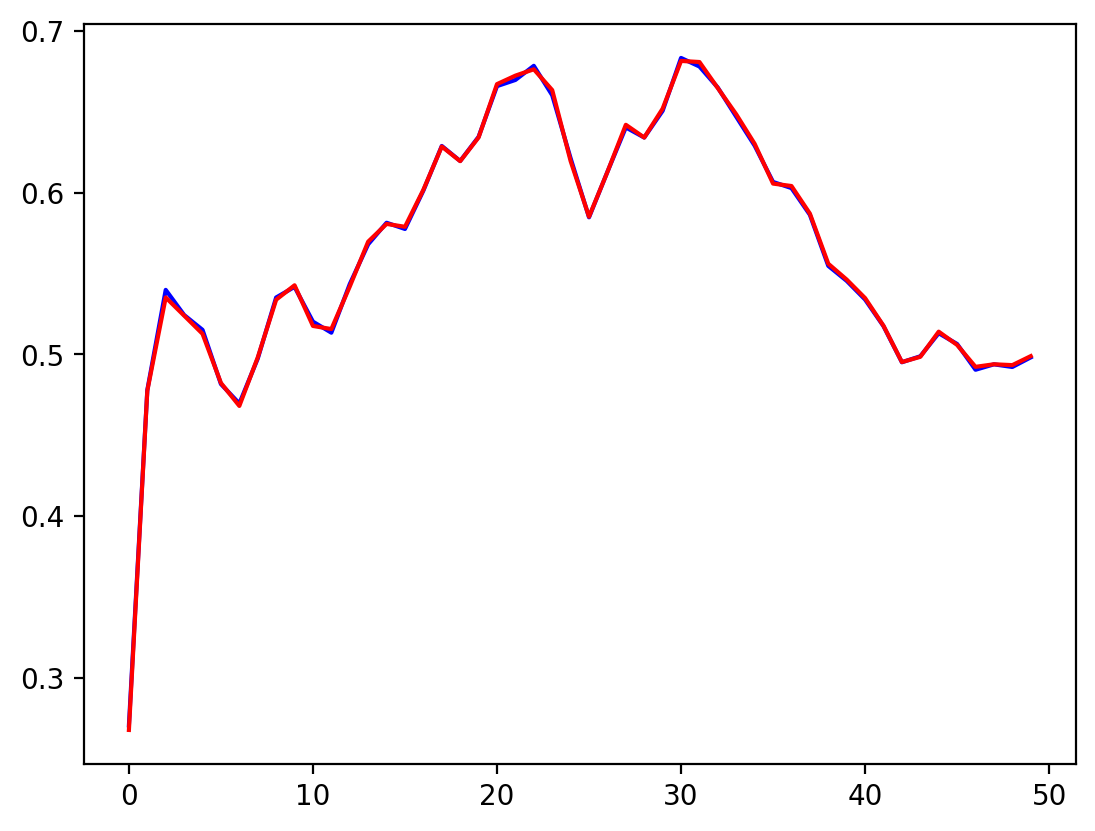

In [ ]:
sample = all_tracts_test_loader.dataset[0][0][0:1].unsqueeze(0).to(device)
output = model(sample)

# Assuming the first element of the tuple is the reconstruction:
reconstructed = output[0]

orig = sample.cpu().detach().numpy()
recon = reconstructed.cpu().detach().numpy()

plt.plot(orig.flatten()[0:100], color='blue', label='Original')
plt.plot(recon.flatten()[0:100], color='red', label='Reconstructed')